# Phishing Detection Agent

## Requierment
- pandas
- scikit-learn
- matplotlib

#### 1. Import libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import pickle
import matplotlib.pyplot as plt

#### 2. Loading datasets and process it
- 0 => safe
- 1 => phishing

Loading dataset...
Undersampling the email dataset to balance with SMS dataset...


,text_combined,label
0,ned deily riyacmorg article 51951867168434095n...,0
1,perl jobs xycnvtnhzperlorg online url job http...,0
2,model 04 28 good morning bill 4 28 could move ...,0
3,request historical curve information sure alre...,0
4,ted leung wxvrjpezsuncom communityone free ope...,0


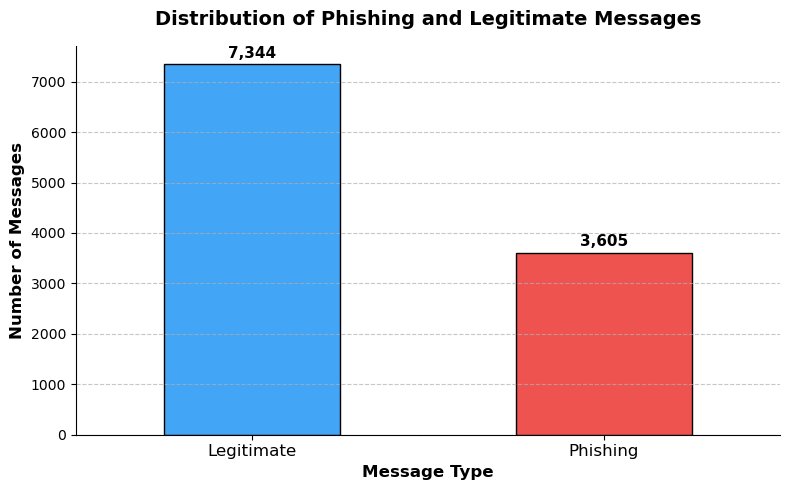

In [2]:
print("Loading dataset...")
df_email = pd.read_csv('phishing_email.csv')
df_sms = pd.read_csv('phishing_sms.csv')

# rename columns to ensure consistency
df_sms = df_sms.rename(columns={'LABEL': 'label', 'TEXT': 'text_combined'})

# replace label values in SMS dataset to match email dataset
df_sms['label'] = df_sms['label'].map({'ham': 0, 'Smishing': 1})

print("Undersampling the email dataset to balance with SMS dataset...")
safe_email = df_email[df_email['label'] == 0]
phishing_email = df_email[df_email['label'] == 1]
safe_email_sampled = safe_email.sample(n=2500, random_state=42)
phishing_email_sampled = phishing_email.sample(n=2500, random_state=42)
df_email_sampled = pd.concat([safe_email_sampled, phishing_email_sampled], ignore_index=True)

# Combine datasets
dataset = pd.concat([df_email_sampled, df_sms], ignore_index=True)

# Ensure the label column is correctly cast to integers
dataset['label'] = pd.to_numeric(dataset['label'], errors='coerce')
dataset = dataset.dropna()
dataset['label'] = dataset['label'].astype(int)

display(dataset.head())

plt.figure(figsize=(8, 5))
ax = dataset['label'].value_counts().plot(kind='bar', color=['#42a5f5', '#ef5350'], edgecolor='black')

plt.title('Distribution of Phishing and Legitimate Messages', fontsize=14, fontweight='bold', pad=15)
plt.xticks(ticks=[1, 0], labels=['Phishing', 'Legitimate'], rotation=0, fontsize=12)
plt.xlabel('Message Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Messages', fontsize=12, fontweight='bold')

# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Clean up aesthetics
plt.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### 4. Spliting the text into trainig and testing sets (80% Trian, 20% Test) then vectorize

In [3]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(dataset['text_combined'], dataset['label'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(stop_words='english')
x_train = vectorizer.fit_transform(x_train_raw)
x_test = vectorizer.transform(x_test_raw)

#### 5. Trainig the model and check the accuracy

True Model Accuracy: 93.97%

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.93      0.99      0.96      1431
    Phishing       0.97      0.85      0.91       759

    accuracy                           0.94      2190
   macro avg       0.95      0.92      0.93      2190
weighted avg       0.94      0.94      0.94      2190



<Figure size 600x400 with 0 Axes>

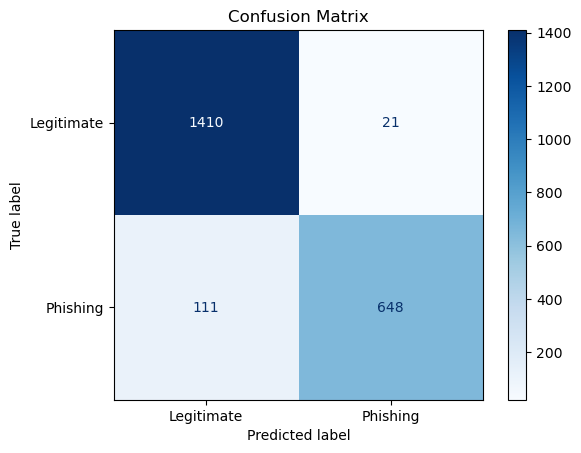

In [4]:
model = LogisticRegression()
model.fit(x_train, y_train)

model_predictions = model.predict(x_test)
accuracy = accuracy_score(y_test, model_predictions)
conf_matrix = confusion_matrix(y_test, model_predictions)

print(f"True Model Accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Classification Report:")
print(classification_report(y_test, model_predictions, target_names=['Legitimate', 'Phishing']))

plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

#### 6. Saving the model and vectorizer

In [5]:
with open('phishing_model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
    
print("Model and vectorizer saved successfully.")
print("You can now run app.py to start the phishing detection agent.")

Model and vectorizer saved successfully.
You can now run app.py to start the phishing detection agent.
